<a href="https://colab.research.google.com/github/Shreyes45/ML-LAB/blob/main/Lab1-dataprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing the dataset
import pandas as pd
df = pd.read_csv("housing.csv")

In [2]:
#Display information of all columns
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [3]:
#Display statistical information of numerical columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
#Count unique labels for ocean proximity
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [5]:
#column having values(>0)
missing_values = df.isnull().sum()
print(missing_values[missing_values>0])

total_bedrooms    207
dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder


In [7]:
diabetes = pd.read_csv('diabetes.csv')
diabetes.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
adult = pd.read_csv('adult.csv')
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [13]:
'''DATA CLEANING
Adult Income Dataset
A. Handling Missing Values'''

# Replace '?' with NaN
adult.replace('?', np.nan, inplace=True)

# Check missing values
adult.isnull().sum()

# Fill categorical missing values with mode
for col in adult.select_dtypes(include='object').columns:
    adult[col] = adult[col].fillna(adult[col].mode()[0])



In [14]:
#Diabetes Dataset
diabetes.isnull().sum()
# Fill numeric missing values with mean
num_cols = diabetes.select_dtypes(include='number').columns
diabetes[num_cols] = diabetes[num_cols].fillna(diabetes[num_cols].mean())
print(diabetes)


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
5              5      116             74              0        0  25.6   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [15]:
#B. Handling Categorical Data
#Adult Income Dataset (Label Encoding)
label_encoders = {}

for col in adult.select_dtypes(include='object').columns:
    le = LabelEncoder()
    adult[col] = le.fit_transform(adult[col])
    label_encoders[col] = le


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
5              5      116             74              0        0  25.6   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

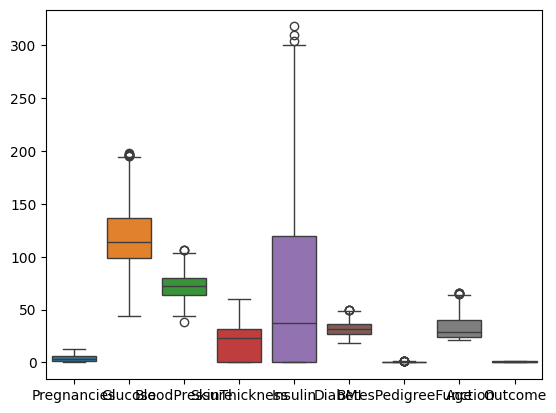

In [9]:
#C. Handling Outliers
num_cols = diabetes.select_dtypes(include='number').columns

Q1 = diabetes[num_cols].quantile(0.25)
Q3 = diabetes[num_cols].quantile(0.75)
IQR = Q3 - Q1

diabetes = diabetes[
    ~((diabetes[num_cols] < (Q1 - 1.5 * IQR)) |
      (diabetes[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]
print(diabetes)
sns.boxplot(data=diabetes)
plt.show()


In [16]:
#DATA TRANSFORMATIONS
#A. Min-Max Scaling (Normalization)
#Diabetes
from sklearn.preprocessing import MinMaxScaler

num_cols = diabetes.select_dtypes(include='number').columns

minmax = MinMaxScaler()
diabetes_scaled = diabetes.copy()

diabetes_scaled[num_cols] = minmax.fit_transform(diabetes[num_cols])

print(diabetes_scaled)

#adult
minmax = MinMaxScaler()
adult_minmax = pd.DataFrame(
    minmax.fit_transform(adult),
    columns=adult.columns
)

adult_minmax.head()


     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.461538  0.675325       0.500000       0.583333  0.000000  0.484277   
1       0.076923  0.266234       0.411765       0.483333  0.000000  0.264151   
2       0.615385  0.902597       0.382353       0.000000  0.000000  0.160377   
3       0.076923  0.292208       0.411765       0.383333  0.295597  0.311321   
5       0.384615  0.467532       0.529412       0.000000  0.000000  0.232704   
..           ...       ...            ...            ...       ...       ...   
763     0.769231  0.370130       0.558824       0.800000  0.566038  0.462264   
764     0.153846  0.506494       0.470588       0.450000  0.000000  0.584906   
765     0.384615  0.500000       0.500000       0.383333  0.352201  0.251572   
766     0.076923  0.532468       0.323529       0.000000  0.000000  0.374214   
767     0.076923  0.318182       0.470588       0.516667  0.000000  0.383648   

     DiabetesPedigreeFunction       Age

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.109589,0.428571,0.145129,0.066667,0.400000,0.666667,0.461538,0.6,0.5,1.0,0.000000,0.0,0.397959,0.95,0.0
1,0.287671,0.428571,0.052451,0.733333,0.533333,0.333333,0.307692,0.0,1.0,1.0,0.000000,0.0,0.500000,0.95,0.0
2,0.150685,0.142857,0.219649,0.466667,0.733333,0.333333,0.769231,0.0,1.0,1.0,0.000000,0.0,0.397959,0.95,1.0
3,0.369863,0.428571,0.100153,1.000000,0.600000,0.333333,0.461538,0.0,0.5,1.0,0.076881,0.0,0.397959,0.95,1.0
4,0.013699,0.428571,0.061708,1.000000,0.600000,0.666667,0.692308,0.6,1.0,0.0,0.000000,0.0,0.295918,0.95,0.0


In [17]:
#B. Standard Scaling (Standardization)
#Diabetes
from sklearn.preprocessing import StandardScaler

num_cols = diabetes.select_dtypes(include='number').columns

standard = StandardScaler()
diabetes_standard = diabetes.copy()

diabetes_standard[num_cols] = standard.fit_transform(diabetes[num_cols])

#Adult standard = StandardScaler()
adult_standard = pd.DataFrame(
    standard.fit_transform(adult),
    columns=adult.columns
)

adult_standard.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,-0.995129,-0.089727,0.351675,-2.397350,-1.197259,0.916138,-0.038505,0.971649,-1.971746,0.70422,-0.144804,-0.217127,-0.034087,0.259694,-0.560845
1,-0.046942,-0.089727,-0.945524,0.183660,-0.419335,-0.410397,-0.542436,-0.900852,0.392384,0.70422,-0.144804,-0.217127,0.772930,0.259694,-0.560845
2,-0.776316,-1.890234,1.394723,-0.848744,0.747550,-0.410397,0.969357,-0.900852,0.392384,0.70422,-0.144804,-0.217127,-0.034087,0.259694,1.783024
3,0.390683,-0.089727,-0.277844,1.216063,-0.030373,-0.410397,-0.038505,-0.900852,-1.971746,0.70422,0.886874,-0.217127,-0.034087,0.259694,1.783024
4,-1.505691,-0.089727,-0.815954,1.216063,-0.030373,0.916138,0.717391,0.971649,0.392384,-1.42001,-0.144804,-0.217127,-0.841104,0.259694,-0.560845
